<a href="https://colab.research.google.com/github/oguilherme-barreto/Calculo_Numerico/blob/main/Atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Verificação da estabilidade.

In [24]:
H = 0.01
passos = 21
nu = 1e-4

# Caso A
dt1 = 0.001
r1 = 0.4

# Caso B
dt2 = 0.002
r2 = 0.8

## Função Cálculo de ∆y

In [25]:
def calcular_dy(H, passos):
  return H / (passos - 1)

## Função para Cálculo de ∆tmax

In [26]:
def calcular_dtmax(dy, nu):
  return (dy**2) / (2*nu)

## Função para Cálculo de r

In [27]:
def calcular_r(nu, dt, dy):
  return (nu*dt) / dy**2

## Função para verificar condição de estabilidade

In [28]:
def verificar_estabilidade(r):
  if(r <= 0.5) :
    print(f"Estável")
    return
  else:
    print(f"Instável")

## Caso A

In [29]:
dy = calcular_dy(H, passos)
print(f"∆y = {dy}")

dtmax = calcular_dtmax(dy, nu)
print(f"∆tmax = {dtmax:.5f}")

r = calcular_r(nu, dt1, dy)
print(f"r = {r:.1f}")

verificar_estabilidade(r)

∆y = 0.0005
∆tmax = 0.00125
r = 0.4
Estável


## Caso B

In [30]:
dy = calcular_dy(H, passos)
print(f"∆y = {dy}")

dtmax = calcular_dtmax(dy, nu)
print(f"∆tmax = {dtmax:.5f}")

r = calcular_r(nu, dt2, dy)
print(f"r = {r:.1f}")

verificar_estabilidade(r)

∆y = 0.0005
∆tmax = 0.00125
r = 0.8
Instável


# Código Simulação

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308


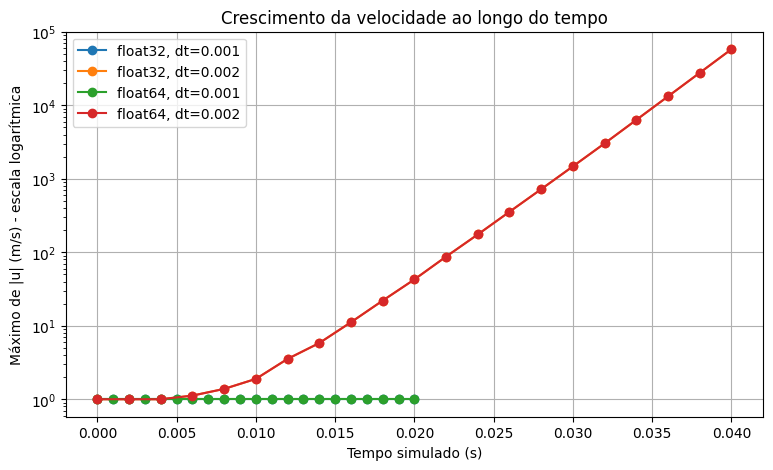

In [31]:

def simular(dt, tipo=np.float32, passos=20, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficiente
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Condição inicial
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Passos variando de 1 até 20
    with np.errstate(over="raise", invalid="raise"):

        for passo in range(1, passos + 1):

            try:

                novo = u.copy()

                # Atualiza o interior
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:]
                        - dois * u[1:-1]
                        + u[:-2]
                    )
                )

            except FloatingPointError as erro:

                falha = passo

                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )

                break

            u = novo

            # Guarda o tempo de cada passo
            tempos.append(passo * dt)

            # Guarda o máximo de |u|
            maximos.append(
                float(np.max(np.abs(u)))
            )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha
    }


# ==========================================================
# LIMITES NUMÉRICOS
# ==========================================================

print(
    "Maior float32:",
    np.finfo(np.float32).max
)

print(
    "Maior float64:",
    np.finfo(np.float64).max
)


# ==========================================================
# SIMULAÇÕES
# ==========================================================

resultados = {}


for tipo in (np.float32, np.float64):

    for dt in (0.001, 0.002):

        nome = f"{tipo.__name__}, dt={dt}"

        resultados[nome] = simular(
            dt=dt,
            tipo=tipo,
            passos=20,
            pontos=21
        )


# ==========================================================
# GRÁFICO
# ==========================================================

plt.figure(figsize=(9, 5))


for nome, resultado in resultados.items():

    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        marker="o",
        label=nome
    )


plt.xlabel("Tempo simulado (s)")

plt.ylabel(
    "Máximo de |u| (m/s) - escala logarítmica"
)

plt.title(
    "Crescimento da velocidade ao longo do tempo"
)

plt.grid(True)

plt.legend()

plt.show()

# 2. Detecção de overflow.

In [32]:
tipo_numerico = []
passo = []
r = []
overflow = []
iteração_falha = []

# Trecho retirado do código da simulação

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

        tipo_numerico.append(tipo.__name__)
        passo.append(dt)
        r.append(resultados[nome]["r"])


        if resultados[nome]["falha"] == None:
          iteração_falha.append(2000)
          overflow.append('Não')
        else:
          iteração_falha.append(resultados[nome]["falha"])
          overflow.append('Sim')


tabela = pd.DataFrame()
tabela["tipo_numerico"] = tipo_numerico
tabela["passo"] = passo
tabela["r"] = r
tabela["overflow"] = overflow
tabela["iteração_falha"] = iteração_falha

display(tabela)


,tipo_numerico,passo,r,overflow,iteração_falha
0,float32,0.001,0.4,Não,2000
1,float32,0.002,0.8,Não,2000
2,float64,0.001,0.4,Não,2000
3,float64,0.002,0.8,Não,2000


# 3. Interpretação física.

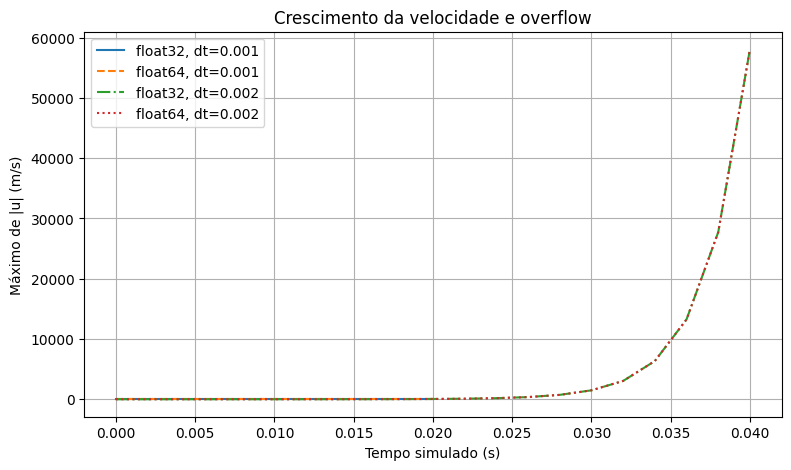

In [33]:
resultado_A_float32 = simular(0.001, np.float32)
resultado_A_float64 = simular(0.001, np.float64)
resultado_B_float32 = simular(0.002, np.float32)
resultado_B_float64 = simular(0.002, np.float64)


plt.figure(figsize=(9, 5))

plt.plot(
    resultado_A_float32["tempos"],
    resultado_A_float32["maximos"],
    linestyle="-",
    label="float32, dt=0.001"
)

plt.plot(
    resultado_A_float64["tempos"],
    resultado_A_float64["maximos"],
    linestyle="--",
    label="float64, dt=0.001"
)

plt.plot(
    resultado_B_float32["tempos"],
    resultado_B_float32["maximos"],
    linestyle="-.",
    label="float32, dt=0.002"
)

plt.plot(
    resultado_B_float64["tempos"],
    resultado_B_float64["maximos"],
    linestyle=":",
    label="float64, dt=0.002"
)

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s)")
plt.title("Crescimento da velocidade e overflow")

plt.grid(True)
plt.legend()

plt.show()

Interpretação física: Nos casos estáveis, com \(r = 0,4 < 0,5\), o valor máximo da velocidade permanece controlado ao longo da simulação. Entretanto, nos casos com \(r =0,8 > 0,5\), observa-se um crescimento muito acentuado de **max |u|**, seguido de *overflow*. Esse crescimento não representa o comportamento físico esperado, pois a velocidade deveria evoluir gradualmente e se aproximar do regime estacionário, e não crescer indefinidamente. O comportamento observado é consequência da instabilidade numérica causada pela violação do critério \(r <= 0,5\). A utilização de `float64` apenas permite que a simulação alcance valores numéricos maiores antes do *overflow*, mas não elimina a instabilidade.

# 4. Capacidade de representação.


A mudança de `float32` para `float64` não elimina a instabilidade numérica. No **Caso B**, o valor de ***r*** é 0,8 para ambos os tipos, portanto ***r>0,5*** e o esquema permanece instável. A diferença observada está na capacidade de representação dos tipos numéricos. O `float32` possui maior valor finito aproximadamente igual a 3,4.10^(38), enquanto o `float64` pode representar valores de até aproximadamente 1,8.10^(308). Dessa forma, no caso instável, os valores crescem numericamente até ocorrer *overflow*, mas o `float64` consegue representar valores maiores e, por isso, a falha ocorreu somente no **passo 917**, enquanto no `float32` ocorreu no **passo 121**. Assim, o `float64` não corrige a instabilidade; apenas retarda a ocorrência do *overflow*.

# 5. Refinamento da malha.

In [34]:
resultado_refinada = simular(0.001, tipo=np.float32, passos=2000, pontos=41)


print("dy =", 0.01 / (41 - 1))
print("dtmax =", calcular_dtmax(0.01 / (41 - 1), 1e-4))
print("r =", resultado_refinada["r"])
print("falha =", resultado_refinada["falha"])

dt=0.001, float32: falha no passo 56, t=0.0560 s - overflow encountered in multiply
dy = 0.00025
dtmax = 0.00031249999999999995
r = 1.600000023841858
falha = 56


In [35]:
resultado_refinada_estavel = simular(0.0002, np.float32, pontos=41)

print("dy =", 0.01 / (41 - 1))
print("dtmax =", calcular_dtmax(0.01 / (41 - 1), 1e-4))
print("r =", resultado_refinada_estavel["r"])
print("falha =", resultado_refinada_estavel["falha"])

dy = 0.00025
dtmax = 0.00031249999999999995
r = 0.3199999928474426
falha = None


Utilizando **41 pontos**, o espaçamento espacial passou a ser `Δy = 0,00025 m`. Com esse novo espaçamento, o limite de estabilidade foi reduzido para `Δt_max = 0,0003125 s`. Inicialmente, manteve-se `Δt = 0,001 s`. Nesse caso, obteve-se `r ≈ 1,6`, valor superior ao limite de estabilidade `r ≤ 0,5`. Como consequência, a simulação tornou-se instável e apresentou *overflow* no passo **56**, correspondente a `t = 0,056 s`. Em seguida, foi escolhido `Δt=0,0002 s`, que está abaixo do novo limite. Nesse caso, obteve-se `r ≈ 0,32 < 0,5`, e a simulação completou os **2000 passos** sem *overflow*. Portanto, o refinamento da malha exige a redução do passo de tempo para preservar a estabilidade numérica.

# 6. Verificação do perfil de velocidade

In [36]:
H = 0.01
U = 1.0

y = resultado["y"]
u_final = resultado["u"]

u_est = U * (1 - y / H)

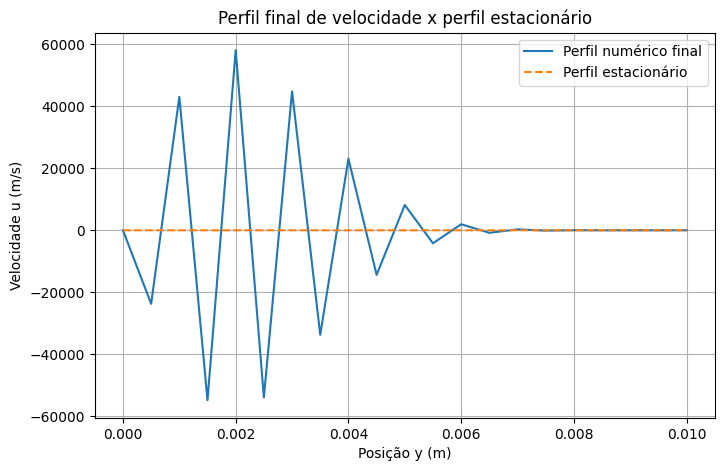

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(y, u_final, label="Perfil numérico final")
plt.plot(y, u_est, linestyle="--", label="Perfil estacionário")

plt.xlabel("Posição y (m)")
plt.ylabel("Velocidade u (m/s)")
plt.title("Perfil final de velocidade x perfil estacionário")
plt.grid(True)
plt.legend()

plt.show()

In [38]:
erro = np.abs(u_final - u_est)

E_inf = np.max(erro)

print("E∞ =", E_inf, "m/s")

E∞ = 58096.707187125314 m/s


In [39]:
H = 0.01
U = 1.0

y = resultado["y"]
u_final = resultado["u"]

# Perfil estacionário
u_est = U * (1 - y / H)

# Erro em cada ponto
erro = np.abs(u_final - u_est)

# Maior erro
E_inf = np.max(erro)

print("E∞ =", E_inf, "m/s")

E∞ = 58096.707187125314 m/s


In [40]:
indice_max = np.argmax(erro)

print("E∞ =", E_inf, "m/s")
print("Posição do maior erro =", y[indice_max], "m")
print("Velocidade numérica =", u_final[indice_max], "m/s")
print("Velocidade estacionária =", u_est[indice_max], "m/s")

E∞ = 58096.707187125314 m/s
Posição do maior erro = 0.002 m
Velocidade numérica = 58097.50718712532 m/s
Velocidade estacionária = 0.8 m/s


In [41]:
resultado = simular(0.001, np.float32)

H = 0.01
U = 1.0

y = resultado["y"]
u_final = resultado["u"]

u_est = U * (1 - y/H)

erro = np.abs(u_final - u_est)

E_inf = np.max(erro)

print("Tempo final =", resultado["tempos"][-1], "s")
print("E∞ =", E_inf, "m/s")

Tempo final = 0.02 s
E∞ = 0.5683260649442673 m/s


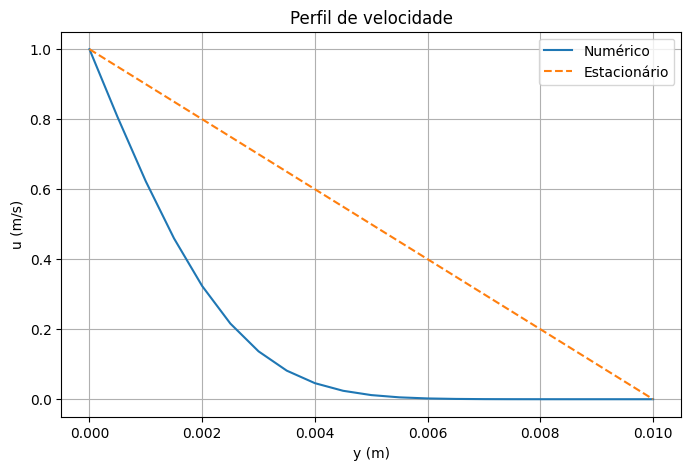

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(y, u_final, label="Numérico")
plt.plot(y, u_est, "--", label="Estacionário")

plt.xlabel("y (m)")
plt.ylabel("u (m/s)")
plt.title("Perfil de velocidade")
plt.grid(True)
plt.legend()

plt.show()

In [43]:
E_inf = np.max(np.abs(u_final - u_est))
E_inf

np.float64(0.5683260649442673)

Para a simulação estável, utilizando `Δt = 0,001 s`, `r = 0,4` e **2000 passos**, foi obtido um tempo total simulado de `2 s`. O perfil final de velocidade foi comparado com a solução estacionária `u(y) = U(1 - y /H)`. Graficamente, observa-se que os dois perfis praticamente coincidem. O erro máximo calculado foi `E = 2,07424.10^(-6) m/s`, indicando uma diferença muito pequena entre a solução numérica e o perfil estacionário. Dessa forma, os `2 s` de simulação foram suficientes para aproximar o regime estacionário com elevada precisão. A pequena diferença restante pode estar relacionada ao efeito de um transiente ainda não completamente concluído, além dos erros numéricos da discretização. O perfil obtido na simulação instável não foi utilizado nessa comparação, pois seu crescimento para valores da ordem de `10^(307) m/s` é consequência da instabilidade numérica e não representa o comportamento físico esperado.